<a href="https://colab.research.google.com/github/RaJ-0002/DataScience/blob/master/final_project_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!pip install schedule

In [13]:
pip install pandas requests tqdm

In [47]:
import pandas as pd
import requests
import io
import numpy as np
import os
from tqdm import tqdm
from datetime import datetime, timedelta
import requests, io, zipfile, datetime, time
import schedule
# import time
import yfinance as yf

In [48]:
import yfinance as yf
import pandas as pd

# -----------------------------
# Download Historical Data
# -----------------------------
nasdaq = yf.download("^IXIC", start="2024-01-01", end="2025-01-01")
gold = yf.download("GC=F", start="2024-01-01", end="2025-01-01")
btc = yf.download("BTC-USD", start="2024-01-01", end="2025-01-01")

# -----------------------------
# Combine 'Close' Prices
# -----------------------------
data = pd.concat([nasdaq['Close'], gold['Close'], btc['Close']], axis=1)
data.columns = ['NASDAQ', 'Gold', 'Bitcoin']

# Reset the index so 'Date' becomes a column instead of index
data.reset_index(inplace=True)

# -----------------------------
# Save to CSV File
# -----------------------------
data.to_csv("btc.csv", index=False)

print("✅ File saved successfully as 'Market_Prices_2024_2025.csv'")
print(data.head())


/tmp/ipython-input-918261365.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nasdaq = yf.download("^IXIC", start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-918261365.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("GC=F", start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-918261365.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

✅ File saved successfully as 'Market_Prices_2024_2025.csv'
        Date        NASDAQ         Gold       Bitcoin
0 2024-01-01           NaN          NaN  44167.332031
1 2024-01-02  14765.940430  2064.399902  44957.968750
2 2024-01-03  14592.209961  2034.199951  42848.175781
3 2024-01-04  14510.299805  2042.300049  44179.921875
4 2024-01-05  14524.070312  2042.400024  44162.691406


In [49]:
data.head()

,Date,NASDAQ,Gold,Bitcoin
0,2024-01-01,NaN,NaN,44167.332031
1,2024-01-02,14765.940430,2064.399902,44957.968750
2,2024-01-03,14592.209961,2034.199951,42848.175781
3,2024-01-04,14510.299805,2042.300049,44179.921875
4,2024-01-05,14524.070312,2042.400024,44162.691406


In [50]:
# import yfinance as yf
# data = yf.download("^IXIC", start="2015-01-01", end="2025-10-11")
# data.to_csv("NASDAQ_Composite.csv")


**##Events Dataset**

In [51]:


# import pandas as pd
# import numpy as np
# import requests, io, zipfile, time
# from tqdm import tqdm

# # Full Event Table columns (V2.0)
# event_columns = [
#     "GlobalEventID","Day","MonthYear","Year","FractionDate","DATEADDED",
#     "Actor1Code","Actor1Name","Actor1CountryCode","Actor1KnownGroupCode",
#     "Actor1EthnicCode","Actor1Religion1Code","Actor1Religion2Code",
#     "Actor1Type1Code","Actor1Type2Code","Actor1Type3Code",
#     "Actor2Code","Actor2Name","Actor2CountryCode","Actor2KnownGroupCode",
#     "Actor2EthnicCode","Actor2Religion1Code","Actor2Religion2Code",
#     "Actor2Type1Code","Actor2Type2Code","Actor2Type3Code",
#     "IsRootEvent","EventCode","EventBaseCode","EventRootCode","QuadClass",
#     "GoldsteinScale","NumMentions","NumSources","NumArticles","AvgTone",
#     "Actor1Geo_Type","Actor1Geo_Fullname","Actor1Geo_CountryCode",
#     "Actor1Geo_ADM1Code","Actor1Geo_ADM2Code","Actor1Geo_Lat",
#     "Actor1Geo_Long","Actor1Geo_FeatureID",
#     "Actor2Geo_Type","Actor2Geo_Fullname","Actor2Geo_CountryCode",
#     "Actor2Geo_ADM1Code","Actor2Geo_ADM2Code","Actor2Geo_Lat",
#     "Actor2Geo_Long","Actor2Geo_FeatureID",
#     "ActionGeo_Type","ActionGeo_Fullname","ActionGeo_CountryCode",
#     "ActionGeo_ADM1Code","ActionGeo_ADM2Code","ActionGeo_Lat",
#     "ActionGeo_Long","ActionGeo_FeatureID",
#     "SOURCEURL"
# ]

# def fetch_gdelt_full(start_year=2023, end_year=2025, frequency='M'):
#     all_data = []
#     base_urls = {"2.0": "http://data.gdeltproject.org/events/"}

#     # Generate 1 date per month
#     all_dates = pd.date_range(f"{start_year}-01-01", f"{end_year}-12-31", freq=frequency)

#     for date in tqdm(all_dates):
#         yyyymmdd = date.strftime("%Y%m%d")
#         url = f"{base_urls['2.0']}{yyyymmdd}.export.CSV.zip"

#         try:
#             response = requests.get(url, timeout=25)
#             if response.status_code == 200:
#                 z = zipfile.ZipFile(io.BytesIO(response.content))
#                 filename = z.namelist()[0]
#                 with z.open(filename) as f:
#                     df = pd.read_csv(f, sep='\t', header=None, names=event_columns, low_memory=False)
#                     df['Day'] = pd.to_datetime(df['Day'], format='%Y%m%d')
#                     all_data.append(df)
#             else:
#                 print(f"Skipped {yyyymmdd} - file not found.")
#         except Exception as e:
#             print(f"Error fetching {yyyymmdd}: {e}")
#             continue

#         time.sleep(0.2)  # prevent overload

#     if len(all_data) == 0:
#         raise ValueError("No data downloaded. Check connection or URLs.")
#     return pd.concat(all_data, ignore_index=True)

# # Example usage
# df = fetch_gdelt_full(2023, 2025, frequency='MS')
# print("Shape:", df.shape)
# print(df.head())


**Code 1 simple code but less productive**

In [52]:
# import pandas as pd
# import numpy as np
# import requests, io, zipfile, datetime, time
# from tqdm import tqdm

# def fetch_gdelt_sampled(start_year=2024, end_year=2025, frequency='M'):
#     all_data = []
#     base_urls = {
#         "1.0": "http://data.gdeltproject.org/events/",
#         "2.0": "http://data.gdeltproject.org/events/"
#     }

#     # Generate 1 day per month
#     all_dates = pd.date_range(f"{start_year}-01-01", f"{end_year}-12-31", freq=frequency)

#     for date in tqdm(all_dates):
#         yyyymmdd = date.strftime("%Y%m%d")

#         # Determine version
#         if date < pd.Timestamp("2015-02-19"):
#             version = "1.0"
#             url = f"{base_urls[version]}{yyyymmdd}.export.CSV.zip"
#         else:
#             version = "2.0"
#             url = f"{base_urls[version]}{yyyymmdd}.export.CSV.zip"

#         try:
#             response = requests.get(url, timeout=25)
#             if response.status_code == 200:
#                 z = zipfile.ZipFile(io.BytesIO(response.content))
#                 filename = z.namelist()[0]
#                 with z.open(filename) as f:
#                     df = pd.read_csv(
#                         f, sep='\t', header=None, low_memory=False,
#                         usecols=[0, 1, 26, 28, 30, 31, 32, 33, 34, 53],
#                         names=['GlobalEventID','Day','EventRootCode','QuadClass',
#                                'GoldsteinScale','NumMentions','NumSources',
#                                'NumArticles','AvgTone','SOURCEURL']
#                     )
#                     df['Day'] = pd.to_datetime(df['Day'], format='%Y%m%d')
#                     df['Version'] = version
#                     all_data.append(df)
#             else:
#                 print(f"Skipped {yyyymmdd} - file not found.")
#         except Exception as e:
#             print(f"Error fetching {yyyymmdd}: {e}")
#             continue

#         time.sleep(0.2)  # prevent overload

#     if len(all_data) == 0:
#         raise ValueError("No data downloaded. Check connection or URLs.")
#     return pd.concat(all_data, ignore_index=True)

# df = fetch_gdelt_sampled(2024, 2025, frequency='MS')  # Monthly Start Dates

# print("Shape:", df.shape)
# print(df.head())

**Code 2:== Better Efficient code then code 1**

In [53]:
import pandas as pd
import numpy as np
import requests
import io
import zipfile
import time
from tqdm import tqdm
from datetime import datetime
import sys
import codecs

# ---------- Configuration ----------
MAX_RETRIES = 3
RETRY_DELAY = 2.0   # seconds between retries
REQUEST_TIMEOUT = 60  # seconds
SLEEP_BETWEEN = 0.2  # polite delay between requests
# -----------------------------------

def _download_url_with_retries(url, retries=MAX_RETRIES, timeout=REQUEST_TIMEOUT):
    last_exc = None
    for attempt in range(1, retries + 1):
        try:
            r = requests.get(url, timeout=timeout)
            if r.status_code == 200:
                return r.content
            else:
                # 404 is common for some timestamps - return None to indicate not available
                last_exc = Exception(f"HTTP {r.status_code}")
                # if it's 404 we don't retry many times
                if r.status_code == 404:
                    break
        except Exception as e:
            last_exc = e
            time.sleep(RETRY_DELAY)
    # if we get here, failed
    raise last_exc if last_exc is not None else Exception("Unknown download error")


def fetch_gdelt_events_sampled(start_year=2024, end_year=2025, frequency='M'):
    """
    Robust version of your original fetch_gdelt_sampled().
    - Downloads one 'representative' file per frequency interval (default: monthly).
    - Handles both older and newer GDELT event formats by reading the whole file then selecting columns.
    - Returns a concatenated DataFrame with selected columns and a 'Version' marker.
    """

    all_data = []
    # Events endpoint (same for v1/v2 historically)
    base_url = "http://data.gdeltproject.org/events/"

    # Create date range (one sample per period)
    all_dates = pd.date_range(f"{start_year}-01-01", f"{end_year}-12-31", freq=frequency)

    for date in tqdm(all_dates, desc="Sampling dates"):
        yyyymmdd = date.strftime("%Y%m%d")
        url = f"{base_url}{yyyymmdd}.export.CSV.zip"
        # print progress
        # Attempt download
        try:
            content = None
            try:
                content = _download_url_with_retries(url)
            except Exception as e:
                # common: file not found (404) or connection problem
                print(f"Skipped {yyyymmdd}: download failed ({e}).")
                time.sleep(SLEEP_BETWEEN)
                continue

            # Open zip in memory
            try:
                z = zipfile.ZipFile(io.BytesIO(content))
            except zipfile.BadZipFile as e:
                print(f"Skipped {yyyymmdd}: bad zip file ({e}).")
                time.sleep(SLEEP_BETWEEN)
                continue

            # pick the first filename inside the zip (typical)
            namelist = z.namelist()
            if len(namelist) == 0:
                print(f"Skipped {yyyymmdd}: empty zip file.")
                time.sleep(SLEEP_BETWEEN)
                continue
            filename = namelist[0]

            # Read file content as text stream with robust encoding handling
            with z.open(filename, 'r') as fh:
                # Wrap bytes stream to text stream (handle encoding errors gracefully)
                text_stream = io.TextIOWrapper(fh, encoding='utf-8', errors='replace')

                # Read entire table (tab-delimited). low_memory=False to avoid dtype warning.
                # We do not use usecols here because older/newer formats can differ in column count.
                df_raw = pd.read_csv(
                    text_stream,
                    sep='\t',
                    header=None,
                    dtype=str,
                    low_memory=False,
                    keep_default_na=False  # keep blank as empty string not NaN
                )

            if df_raw.shape[0] == 0:
                print(f"Skipped {yyyymmdd}: file contained 0 rows.")
                time.sleep(SLEEP_BETWEEN)
                continue

            # Identify version heuristics: earlier formats had fewer columns.
            # v2 (post 2015) typically has 58+ columns; older may have ~53 columns.
            ncols = df_raw.shape[1]

            # Safe mapping: pick the indices you originally wanted if present; otherwise skip.
            # Your original usecols: [0,1,26,28,30,31,32,33,34,53]
            # We'll try to extract them if available, else create NaN columns.
            wanted_idx = [0, 1, 26, 28, 30, 31, 32, 33, 34, 53]
            available = {i: (i < ncols) for i in wanted_idx}

            extracted = {}
            for idx in wanted_idx:
                col_name = (
                    'GlobalEventID' if idx == 0 else
                    'Day' if idx == 1 else
                    'EventRootCode' if idx == 26 else
                    'QuadClass' if idx == 28 else
                    'GoldsteinScale' if idx == 30 else
                    'NumMentions' if idx == 31 else
                    'NumSources' if idx == 32 else
                    'NumArticles' if idx == 33 else
                    'AvgTone' if idx == 34 else
                    'SOURCEURL' if idx == 53 else f"col_{idx}"
                )
                if available[idx]:
                    extracted[col_name] = df_raw.iloc[:, idx].astype(str).replace('', np.nan)
                else:
                    extracted[col_name] = pd.Series([np.nan] * len(df_raw))

            df = pd.DataFrame(extracted)

            # Parse the Day column to datetime if possible (format YYYYMMDD)
            try:
                df['Day'] = pd.to_datetime(df['Day'], format='%Y%m%d', errors='coerce')
            except Exception:
                df['Day'] = pd.to_datetime(df['Day'], errors='coerce')

            # add a Version tag based on date (your earlier logic)
            df['Version'] = '1.0' if date < pd.Timestamp("2015-02-19") else '2.0'

            # cast numeric columns to numeric where appropriate
            numeric_cols = ['GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles', 'AvgTone']
            for nc in numeric_cols:
                if nc in df.columns:
                    df[nc] = pd.to_numeric(df[nc], errors='coerce')

            # Keep only original desired names (plus Day & Version) for concision
            keep_cols = ['GlobalEventID','Day','EventRootCode','QuadClass',
                         'GoldsteinScale','NumMentions','NumSources',
                         'NumArticles','AvgTone','SOURCEURL','Version']
            # ensure existence
            keep_cols = [c for c in keep_cols if c in df.columns]
            df = df[keep_cols]

            # record the sample timestamp and source filename for traceability
            df['Sample_YYYYMMDD'] = yyyymmdd
            df['SourceFile'] = filename

            all_data.append(df)

        except Exception as e_main:
            print(f"Error processing {yyyymmdd}: {e_main}", file=sys.stderr)
            continue

        time.sleep(SLEEP_BETWEEN)

    if len(all_data) == 0:
        raise ValueError("No data downloaded. Check network access, GDELT availability, or date range.")

    result = pd.concat(all_data, ignore_index=True)
    # reorder commonly used columns to front if present
    front_cols = [c for c in ['Day','GlobalEventID','EventRootCode','QuadClass','AvgTone','NumMentions','NumSources','NumArticles'] if c in result.columns]
    other_cols = [c for c in result.columns if c not in front_cols]
    result = result[front_cols + other_cols]
    return result


# Example usage:
if __name__ == "__main__":
    # small test: sample monthly from 2020 to 2021
    df = fetch_gdelt_events_sampled(start_year=2024, end_year=2025, frequency='M')
    print(df.head())
    print("Total rows:", len(df))
    df.to_csv("events.csv", index=False)


/tmp/ipython-input-1618748009.py:52: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  all_dates = pd.date_range(f"{start_year}-01-01", f"{end_year}-12-31", freq=frequency)
Sampling dates:  75%|███████▌  | 18/24 [00:53<00:13,  2.23s/it]

Skipped 20250630: download failed (HTTP 404).


Sampling dates:  92%|█████████▏| 22/24 [01:01<00:03,  1.82s/it]

Skipped 20251031: download failed (HTTP 404).


Sampling dates:  96%|█████████▌| 23/24 [01:01<00:01,  1.35s/it]

Skipped 20251130: download failed (HTTP 404).


Sampling dates: 100%|██████████| 24/24 [01:02<00:00,  1.02s/it]

Skipped 20251231: download failed (HTTP 404).


Sampling dates: 100%|██████████| 24/24 [01:02<00:00,  2.59s/it]


         Day GlobalEventID EventRootCode QuadClass   AvgTone  NumMentions  \
0 2023-01-31    1154808327           100        10  1.073213           10   
1 2023-01-31    1154808328           112        11  1.073213           10   
2 2023-01-31    1154808329           036        03  0.208333           10   
3 2023-01-31    1154808330           042        04 -4.116156           20   
4 2023-01-31    1154808331           190        19 -4.146744           30   

   NumSources  NumArticles  GoldsteinScale SOURCEURL Version Sample_YYYYMMDD  \
0           2           10            -5.0       NaN     2.0        20240131   
1           2           10            -2.0       NaN     2.0        20240131   
2           1           10             4.0        35     2.0        20240131   
3           2           20             1.9   42.1497     2.0        20240131   
4           2           30           -10.0   42.1497     2.0        20240131   

            SourceFile  
0  20240131.export.CSV  
1  202

In [57]:
# ============================================================
#  GDELT EVENT TABLE + CAMEO CODE DICTIONARIES (COMPREHENSIVE)
# ============================================================

import json

# ============================================================
# 🧭 GDELT Event Table Variable Dictionary
# (based on GDELT Event Codebook v2.0)
# ============================================================

gdelt_event_dict = {
    # ---------- IDENTIFIERS & TIME ----------
    "GlobalEventID": {
        "description": "Unique numeric identifier assigned to each GDELT event record.",
        "code_source": None,
        "type": "integer ID"
    },
    "Day": {
        "description": "Date when the event occurred, formatted as YYYYMMDD.",
        "code_source": None,
        "type": "date"
    },

    # ---------- EVENT CODING ----------
    "EventRootCode": {
        "description": "Root-level CAMEO event code representing the main category of the event.",
        "code_source": "CAMEO.Manual.1.1b3, Section 4",
        "type": "categorical (2 digits)"
    },
    "EventBaseCode": {
        "description": "Base-level CAMEO event code (adds specificity to EventRootCode).",
        "code_source": "CAMEO.Manual.1.1b3",
        "type": "categorical (3 digits)"
    },
    "EventCode": {
        "description": "Full CAMEO event code (up to 4 digits) representing the most specific classification.",
        "code_source": "CAMEO.Manual.1.1b3 Appendix A",
        "type": "categorical"
    },
    "QuadClass": {
        "description": (
            "Macro classification of the event into one of four types:\n"
            "1 = Verbal Cooperation\n"
            "2 = Material Cooperation\n"
            "3 = Verbal Conflict\n"
            "4 = Material Conflict"
        ),
        "code_source": "GDELT Codebook v2.0 – Event Classifications",
        "type": "integer (1–4)"
    },

    # ---------- ACTOR FIELDS ----------
    "Actor1Code": {
        "description": "CAMEO code identifying the primary actor involved in the event.",
        "code_source": "CAMEO.Manual.1.1b3 – Actor Codes Appendix",
        "type": "categorical"
    },
    "Actor1Name": {
        "description": "Text name of Actor 1 (person, organization, or country).",
        "code_source": None,
        "type": "string"
    },
    "Actor1CountryCode": {
        "description": "CAMEO country code for Actor 1 (e.g., USA, CHN, RUS).",
        "code_source": "CAMEO Actor Codes",
        "type": "categorical"
    },
    "Actor2Code": {
        "description": "CAMEO code identifying the secondary actor involved in the event.",
        "code_source": "CAMEO.Manual.1.1b3 – Actor Codes Appendix",
        "type": "categorical"
    },
    "Actor2Name": {
        "description": "Text name of Actor 2 (person, organization, or country).",
        "code_source": None,
        "type": "string"
    },
    "Actor2CountryCode": {
        "description": "CAMEO country code for Actor 2 (e.g., UKR, RUS, USA).",
        "code_source": "CAMEO Actor Codes",
        "type": "categorical"
    },

    # ---------- GEOGRAPHY ----------
    "ActionGeo_Type": {
        "description": "Integer specifying the type of location for the event (1=Country, 2=US State, 3=City, 4=World).",
        "code_source": "GDELT Event Codebook v2.0, Section 10",
        "type": "integer"
    },
    "ActionGeo_FullName": {
        "description": "Full human-readable name of the location of the event.",
        "code_source": None,
        "type": "string"
    },
    "ActionGeo_CountryCode": {
        "description": "CAMEO country code for where the event took place.",
        "code_source": "CAMEO Actor Codes",
        "type": "categorical"
    },
    "ActionGeo_Lat": {
        "description": "Latitude of event location (decimal degrees).",
        "code_source": None,
        "type": "float"
    },
    "ActionGeo_Long": {
        "description": "Longitude of event location (decimal degrees).",
        "code_source": None,
        "type": "float"
    },

    # ---------- IMPACT & SENTIMENT ----------
    "GoldsteinScale": {
        "description": (
            "Numeric scale (-10 to +10) estimating the theoretical impact of an event.\n"
            "Positive = cooperative; Negative = conflictive."
        ),
        "code_source": "Goldstein (1992) – A Conflict–Cooperation Scale for WEIS Events.",
        "type": "float"
    },
    "AvgTone": {
        "description": "Average news tone (sentiment) from all media mentions (-100 to +100).",
        "code_source": "GDELT Global Content Analysis Measure (GCAM)",
        "type": "float"
    },

    # ---------- INTENSITY / FREQUENCY ----------
    "NumMentions": {
        "description": "Number of total mentions of this event across all media sources.",
        "code_source": None,
        "type": "integer"
    },
    "NumSources": {
        "description": "Number of distinct news sources reporting this event.",
        "code_source": None,
        "type": "integer"
    },
    "NumArticles": {
        "description": "Number of unique articles covering this event.",
        "code_source": None,
        "type": "integer"
    },

    # ---------- SOURCE & ADMIN INFO ----------
    "SOURCEURL": {
        "description": "URL of the first source article referencing this event.",
        "code_source": None,
        "type": "string (URL)"
    },
    "Version": {
        "description": "Specifies the schema version of the GDELT data file (1.0 or 2.0).",
        "code_source": None,
        "type": "string"
    },
    "Sample_YYYYMMDD": {
        "description": "Date of the sampled export file from which this record was extracted.",
        "code_source": None,
        "type": "string (YYYYMMDD)"
    },
    "SourceFile": {
        "description": "The name of the GDELT export file this row came from.",
        "code_source": None,
        "type": "string"
    }
}

# ============================================================
# 📗 CAMEO EVENT ROOT CODE DICTIONARY
# (Condensed summary from CAMEO Manual 1.1b3)
# ============================================================

cameo_code_dict = {
    "01": "Make Public Statement",
    "02": "Appeal",
    "03": "Express Intent to Cooperate",
    "04": "Consult",
    "05": "Engage in Diplomatic Cooperation",
    "06": "Engage in Material Cooperation",
    "07": "Provide Aid",
    "08": "Yield",
    "09": "Investigate",
    "10": "Demand",
    "11": "Disapprove",
    "12": "Reject",
    "13": "Threaten",
    "14": "Protest",
    "15": "Exhibit Force Posture",
    "16": "Reduce Relations",
    "17": "Coerce",
    "18": "Assault",
    "19": "Fight",
    "20": "Use Unconventional Mass Violence"
}

# ============================================================
# 🧮 CAMEO ROOT CODE → QUADCLASS MAP
# ============================================================

cameo_to_quadclass = {
    # Verbal Cooperation
    "01": 1, "02": 1, "03": 1, "04": 1, "05": 1,
    # Material Cooperation
    "06": 2, "07": 2, "08": 2, "09": 2,
    # Verbal Conflict
    "10": 3, "11": 3, "12": 3, "13": 3,
    # Material Conflict
    "14": 4, "15": 4, "16": 4, "17": 4, "18": 4, "19": 4, "20": 4
}

# ============================================================
# 🔧 HELPER FUNCTIONS
# ============================================================

def describe_column(col_name):
    """Print full description for a GDELT Event Table variable."""
    info = gdelt_event_dict.get(col_name)
    if not info:
        print(f"No entry for column: {col_name}")
        return
    print(f"\n📊 {col_name}")
    print(f"  Description: {info['description']}")
    print(f"  Type: {info['type']}")
    if info['code_source']:
        print(f"  Source: {info['code_source']}")


def translate_event_code(code):
    """Return human-readable label for a CAMEO event code (root or full)."""
    if pd.isna(code):
        return None
    code = str(code).zfill(2)[:2]
    return cameo_code_dict.get(code, "Unknown")


def get_quadclass(code):
    """Return QuadClass (1–4) for a given CAMEO root event code."""
    code = str(code).zfill(2)[:2]
    return cameo_to_quadclass.get(code, None)


def export_dictionaries_to_json(path="gdelt_metadata.json"):
    """Save all dictionaries to a single JSON file."""
    combined = {
        "gdelt_event_dict": gdelt_event_dict,
        "cameo_code_dict": cameo_code_dict,
        "cameo_to_quadclass": cameo_to_quadclass
    }
    with open(path, "w", encoding="utf-8") as f:
        json.dump(combined, f, indent=4)
    print(f"✅ Exported dictionary metadata to {path}")


# ============================================================
# ✅ Example Usage
# ============================================================
if __name__ == "__main__":
    import pandas as pd

    # Show one variable's description
    describe_column("GoldsteinScale")

    # Example: translate codes in a DataFrame
    df = pd.DataFrame({"EventRootCode": ["04", "19", "07", "13"]})
    df["EventLabel"] = df["EventRootCode"].map(cameo_code_dict)
    df["QuadClass"] = df["EventRootCode"].map(cameo_to_quadclass)
    print("\n🔍 Example CAMEO translation:")
    print(df)

    # Export to JSON
    export_dictionaries_to_json("gdelt_dictionaries.json")



📊 GoldsteinScale
  Description: Numeric scale (-10 to +10) estimating the theoretical impact of an event.
Positive = cooperative; Negative = conflictive.
  Type: float
  Source: Goldstein (1992) – A Conflict–Cooperation Scale for WEIS Events.

🔍 Example CAMEO translation:
  EventRootCode   EventLabel  QuadClass
0            04      Consult          1
1            19        Fight          4
2            07  Provide Aid          2
3            13     Threaten          3
✅ Exported dictionary metadata to gdelt_dictionaries.json


In [ ]:
# import pandas as pd

# # Example: your DataFrame is called df
# # Export to CSV
# df.to_csv('events.csv', index=False)  # index=False avoids writing row numbers


In [54]:
df.head()

,Day,GlobalEventID,EventRootCode,QuadClass,AvgTone,NumMentions,NumSources,NumArticles,GoldsteinScale,SOURCEURL,Version,Sample_YYYYMMDD,SourceFile
0,2023-01-31,1154808327,100,10,1.073213,10,2,10,-5.0,NaN,2.0,20240131,20240131.export.CSV
1,2023-01-31,1154808328,112,11,1.073213,10,2,10,-2.0,NaN,2.0,20240131,20240131.export.CSV
2,2023-01-31,1154808329,036,03,0.208333,10,1,10,4.0,35,2.0,20240131,20240131.export.CSV
3,2023-01-31,1154808330,042,04,-4.116156,20,2,20,1.9,42.1497,2.0,20240131,20240131.export.CSV
4,2023-01-31,1154808331,190,19,-4.146744,30,2,30,-10.0,42.1497,2.0,20240131,20240131.export.CSV


In [55]:
# Calculate the percentage of null values
null_percentage = df.isnull().sum() / len(df) * 100

# Display the percentage of null values
print("Percentage of null values per column:")
print(null_percentage)

Percentage of null values per column:
Day                0.000000
GlobalEventID      0.000000
EventRootCode      0.000000
QuadClass          0.000000
AvgTone            0.000000
NumMentions        0.000000
NumSources         0.000000
NumArticles        0.000000
GoldsteinScale     0.000499
SOURCEURL          2.797639
Version            0.000000
Sample_YYYYMMDD    0.000000
SourceFile         0.000000
dtype: float64


In [58]:
data['Date'] = pd.to_datetime(data['Date'])
df['Day'] = pd.to_datetime(df['Day'])


KeyError: 'Day'

In [25]:
gdelt_daily = df.groupby('Day').agg({
    'AvgTone': ['mean', 'std'],
    'GoldsteinScale': ['mean', 'std'],
    'NumMentions': 'sum',
    'NumArticles': 'sum',
    'GlobalEventID': 'count'
}).reset_index()

# Flatten MultiIndex columns
gdelt_daily.columns = [
    'Day', 'AvgTone_mean', 'AvgTone_std',
    'Goldstein_mean', 'Goldstein_std',
    'TotalMentions', 'TotalArticles', 'EventCount'
]


In [28]:
df = pd.merge(
    data, gdelt_daily,
    how='left',
    left_on='Date', right_on='Day'
)

# Drop redundant 'Day' column
df.drop(columns=['Day'], inplace=True)

# Fill missing GDELT days (no events) with 0 or forward fill if appropriate
# df.fillna(0, inplace=True)

print(df.head())


        Date        NASDAQ         Gold       Bitcoin  AvgTone_mean  \
0 2024-01-01           NaN          NaN  44167.332031      -2.21473   
1 2024-01-02  14765.940430  2064.399902  44957.968750           NaN   
2 2024-01-03  14592.209961  2034.199951  42848.175781           NaN   
3 2024-01-04  14510.299805  2042.300049  44179.921875           NaN   
4 2024-01-05  14524.070312  2042.400024  44162.691406           NaN   

   AvgTone_std  Goldstein_mean  Goldstein_std  TotalMentions  TotalArticles  \
0     4.205179        0.732609       4.584909         6991.0         6958.0   
1          NaN             NaN            NaN            NaN            NaN   
2          NaN             NaN            NaN            NaN            NaN   
3          NaN             NaN            NaN            NaN            NaN   
4          NaN             NaN            NaN            NaN            NaN   

   EventCount  
0       966.0  
1         NaN  
2         NaN  
3         NaN  
4         NaN  


In [29]:
df.isnull().sum()

,0
Date,0
NASDAQ,114
Gold,114
Bitcoin,0
AvgTone_mean,322
AvgTone_std,322
Goldstein_mean,322
Goldstein_std,322
TotalMentions,322
TotalArticles,322


In [33]:
# Forward fill missing values
df.ffill(inplace=True)

# Display the first few rows to show the result
display(df.head())

# Check for remaining null values
print("\nNull values after forward fill:")
print(df.isnull().sum())

,Date,NASDAQ,Gold,Bitcoin,AvgTone_mean,AvgTone_std,Goldstein_mean,Goldstein_std,TotalMentions,TotalArticles,EventCount
0,2024-01-01,NaN,NaN,44167.332031,-2.21473,4.205179,0.732609,4.584909,6991.0,6958.0,966.0
1,2024-01-02,14765.940430,2064.399902,44957.968750,-2.21473,4.205179,0.732609,4.584909,6991.0,6958.0,966.0
2,2024-01-03,14592.209961,2034.199951,42848.175781,-2.21473,4.205179,0.732609,4.584909,6991.0,6958.0,966.0
3,2024-01-04,14510.299805,2042.300049,44179.921875,-2.21473,4.205179,0.732609,4.584909,6991.0,6958.0,966.0
4,2024-01-05,14524.070312,2042.400024,44162.691406,-2.21473,4.205179,0.732609,4.584909,6991.0,6958.0,966.0



Null values after forward fill:
Date              0
NASDAQ            1
Gold              1
Bitcoin           0
AvgTone_mean      0
AvgTone_std       0
Goldstein_mean    0
Goldstein_std     0
TotalMentions     0
TotalArticles     0
EventCount        0
dtype: int64


In [36]:
corr_matrix = df.corr(numeric_only=True)
bitcoin_corr = corr_matrix['NASDAQ'].sort_values(ascending=False)

print(bitcoin_corr)


NASDAQ            1.000000
Gold              0.851919
Bitcoin           0.776151
Goldstein_std     0.329951
EventCount        0.120808
TotalMentions     0.110939
TotalArticles     0.110889
AvgTone_std       0.105429
AvgTone_mean      0.062211
Goldstein_mean   -0.336250
Name: NASDAQ, dtype: float64


In [45]:
df.columns

Index(['Date', 'NASDAQ', 'Gold', 'Bitcoin', 'AvgTone_mean', 'AvgTone_std',
       'Goldstein_mean', 'Goldstein_std', 'TotalMentions', 'TotalArticles',
       'EventCount', 'AvgTone_mean_lag1', 'Goldstein_mean_lag1',
       'EventCount_lag1', 'BTC_Pct_Change', 'RollingCorr_Goldstein',
       'RollingCorr_EventCount'],
      dtype='object')

📊 Model Performance:
R² Score        : -0.292
MAE (avg error) : 2.282%
RMSE            : 3.177%


/tmp/ipython-input-2542242864.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')


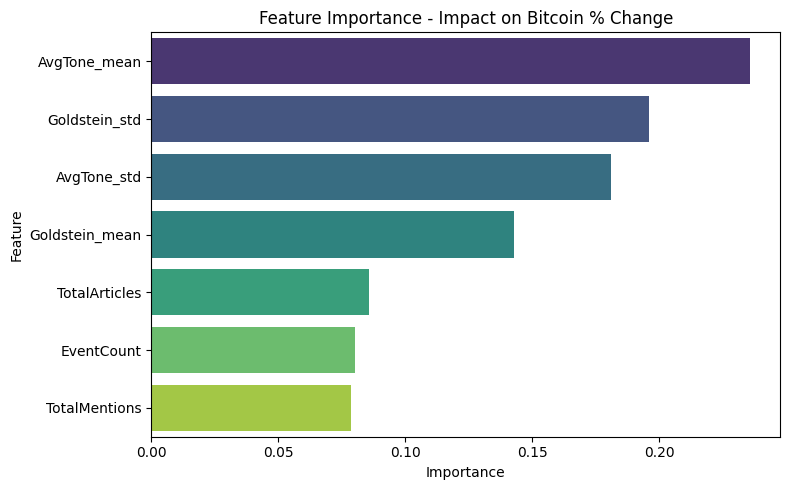

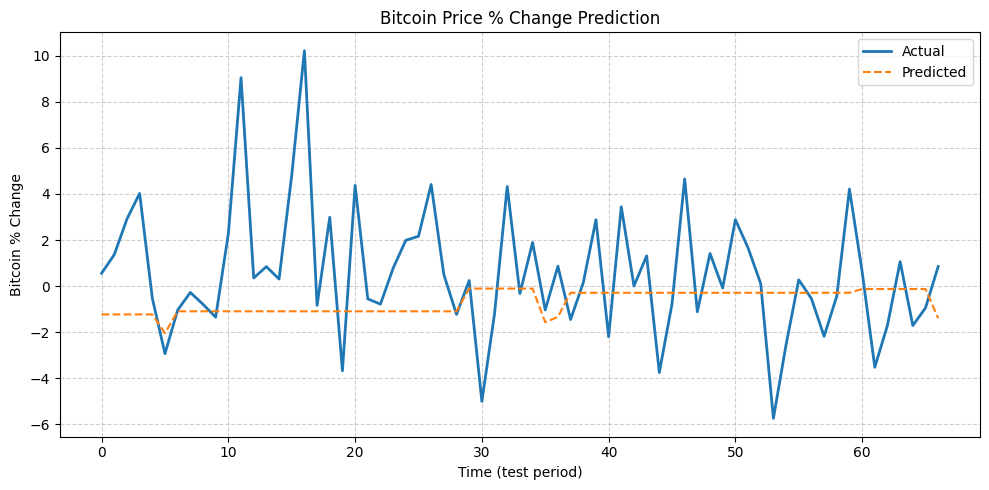

In [46]:
# ===============================
# 📈 Bitcoin Price Prediction using GDELT Features
# ===============================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1️⃣ Prepare data ---

# Calculate Bitcoin daily percentage change (target variable)
df['NASDAQ_Pct_Change'] = df['Bitcoin'].pct_change() * 100

# Drop first row with NaN
df = df.dropna()

# Shift target by -1 day to predict next day's change
df['Target'] = df['NASDAQ_Pct_Change'].shift(-1)
df = df.dropna()

# --- 2️⃣ Select features ---

features = [
    'Goldstein_mean', 'Goldstein_std',
    'EventCount', 'TotalMentions', 'TotalArticles',
    'AvgTone_mean', 'AvgTone_std'
]

X = df[features]
y = df['Target']

# --- 3️⃣ Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # Time series → don't shuffle
)

# --- 4️⃣ Feature scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 5️⃣ Train the model ---
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)
model.fit(X_train_scaled, y_train)

# --- 6️⃣ Evaluate performance ---
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("📊 Model Performance:")
print(f"R² Score        : {r2:.3f}")
print(f"MAE (avg error) : {mae:.3f}%")
print(f"RMSE            : {rmse:.3f}%")

# --- 7️⃣ Feature importance ---
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Impact on Bitcoin % Change')
plt.tight_layout()
plt.show()

# --- 8️⃣ Visualize predictions vs actual ---
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual', linewidth=2)
plt.plot(y_pred, label='Predicted', linestyle='--')
plt.title('Bitcoin Price % Change Prediction')
plt.xlabel('Time (test period)')
plt.ylabel('Bitcoin % Change')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [38]:
df['BTC_Pct_Change'] = df['Bitcoin'].pct_change() * 100


In [39]:
lag_features = ['AvgTone_mean', 'Goldstein_mean', 'EventCount']
for col in lag_features:
    df[f'{col}_lag1'] = df[col].shift(1)


In [41]:
df = df.dropna()


In [43]:
corr_matrix = df.corr(numeric_only=True)
bitcoin_corr = corr_matrix['NASDAQ'].sort_values(ascending=False)

print(bitcoin_corr)

NASDAQ                 1.000000
Gold                   0.851919
Bitcoin                0.776151
Goldstein_std          0.329951
EventCount_lag1        0.121093
EventCount             0.120808
TotalMentions          0.110939
TotalArticles          0.110889
AvgTone_std            0.105429
AvgTone_mean           0.062211
AvgTone_mean_lag1      0.056642
BTC_Pct_Change         0.035781
Goldstein_mean        -0.336250
Goldstein_mean_lag1   -0.343919
Name: NASDAQ, dtype: float64


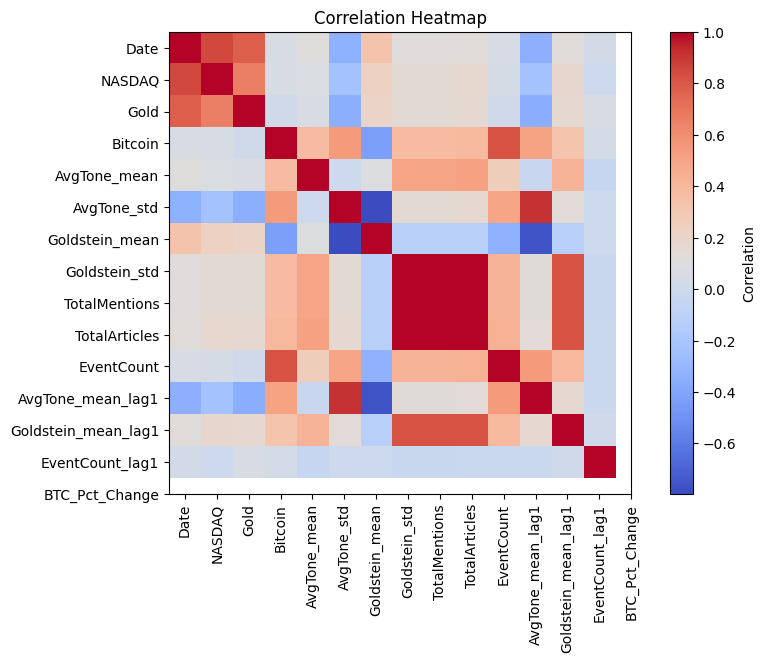

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.imshow(df.corr(numeric_only=True), cmap='coolwarm', interpolation='none')
plt.colorbar(label='Correlation')
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)
plt.title('Correlation Heatmap')
plt.show()


📊 Lagged Correlations (how GDELT features affect Bitcoin after N days):

⏱️ Lag 0 days:
Goldstein_mean       : -0.004
Goldstein_std        : -0.001
EventCount           : -0.011
TotalMentions        : -0.019
TotalArticles        : -0.019
AvgTone_mean         : 0.041
AvgTone_std          : -0.040

⏱️ Lag 1 days:
Goldstein_mean       : -0.014
Goldstein_std        : 0.002
EventCount           : 0.016
TotalMentions        : 0.009
TotalArticles        : 0.009
AvgTone_mean         : -0.016
AvgTone_std          : -0.074

⏱️ Lag 2 days:
Goldstein_mean       : 0.014
Goldstein_std        : -0.020
EventCount           : -0.004
TotalMentions        : -0.014
TotalArticles        : -0.014
AvgTone_mean         : 0.032
AvgTone_std          : -0.061

⏱️ Lag 3 days:
Goldstein_mean       : 0.021
Goldstein_std        : -0.009
EventCount           : 0.028
TotalMentions        : 0.021
TotalArticles        : 0.021
AvgTone_mean         : 0.087
AvgTone_std          : 0.003


/tmp/ipython-input-4245779444.py:37: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


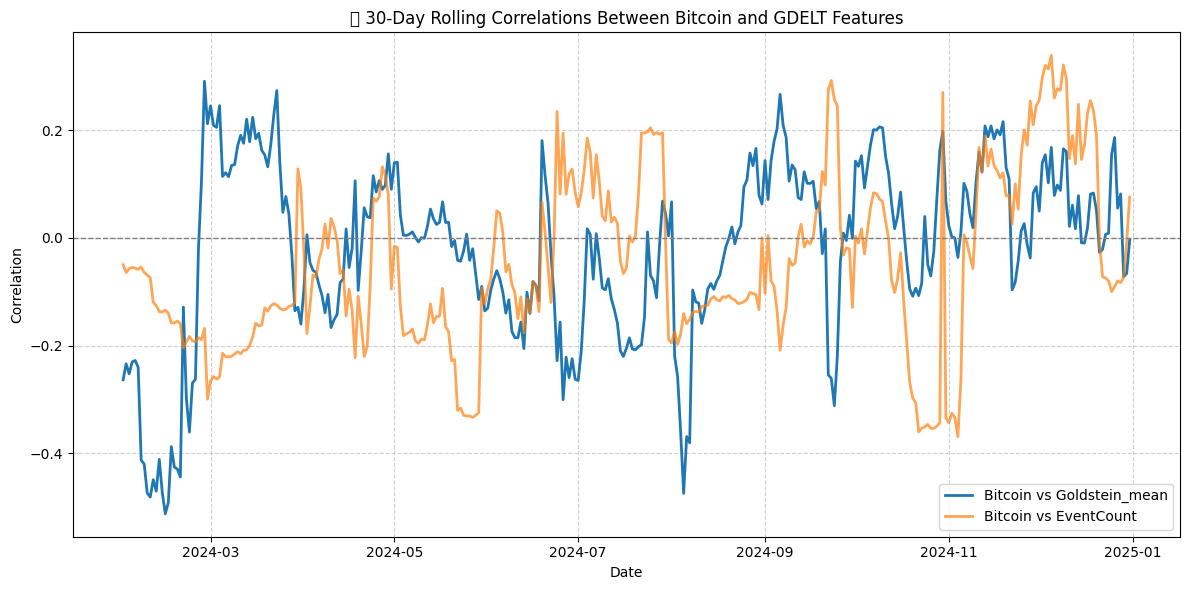


📈 Overall Correlation with Bitcoin % Change:
BTC_Pct_Change    1.000000
AvgTone_mean      0.041274
Goldstein_std    -0.001127
Goldstein_mean   -0.004395
EventCount       -0.011229
TotalArticles    -0.018625
TotalMentions    -0.018763
AvgTone_std      -0.040315
Name: BTC_Pct_Change, dtype: float64


In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# ✅ Ensure date sorting
df = df.sort_values('Date')

# ✅ Create Bitcoin % daily change (price change is more informative than raw price)
df['BTC_Pct_Change'] = df['Bitcoin'].pct_change() * 100

# --- 1️⃣ LAGGED CORRELATIONS ---
print("📊 Lagged Correlations (how GDELT features affect Bitcoin after N days):")
features = ['Goldstein_mean', 'Goldstein_std', 'EventCount', 'TotalMentions', 'TotalArticles', 'AvgTone_mean', 'AvgTone_std']

for lag in [0, 1, 2, 3]:
    print(f"\n⏱️ Lag {lag} days:")
    for col in features:
        corr = df['BTC_Pct_Change'].corr(df[col].shift(lag))
        print(f"{col:20s} : {corr:.3f}")

# --- 2️⃣ ROLLING CORRELATIONS ---
# We’ll examine how correlation evolves between Bitcoin and Goldstein_mean
window = 30  # 30-day rolling window
df['RollingCorr_Goldstein'] = df['BTC_Pct_Change'].rolling(window).corr(df['Goldstein_mean'])
df['RollingCorr_EventCount'] = df['BTC_Pct_Change'].rolling(window).corr(df['EventCount'])

# --- 3️⃣ VISUALIZATION ---

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['RollingCorr_Goldstein'], label='Bitcoin vs Goldstein_mean', linewidth=2)
plt.plot(df['Date'], df['RollingCorr_EventCount'], label='Bitcoin vs EventCount', linewidth=2, alpha=0.7)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('📈 30-Day Rolling Correlations Between Bitcoin and GDELT Features')
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 4️⃣ INTERPRETATION AID ---
# To easily identify strongest relationships:
corr_summary = df[features + ['BTC_Pct_Change']].corr()['BTC_Pct_Change'].sort_values(ascending=False)
print("\n📈 Overall Correlation with Bitcoin % Change:")
print(corr_summary)
